In [1]:
# Create output directory for plots
import os
os.makedirs('plots', exist_ok=True)
print("Created 'plots' directory for saving EDA visualizations.")

Created 'plots' directory for saving EDA visualizations.


In [2]:
!pwd

/auto/vestec1-elixir/home/mamedove/Scripts/experimental


In [3]:
# Pollen Dataset EDA - Class Distribution Analysis
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Plot settings for better readability
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Dataset path - full raw directory (no train/val split)
DATA_DIR = Path("/storage/praha1/home/mamedove/00_Data/2025_Pollen/Multi_class/multi-class-set/selection4class_training_27052024")

print("Dataset path configured.")
print(f"Data dir: {DATA_DIR}")
print(f"Exists: {DATA_DIR.exists()}")

Dataset path configured.
Data dir: /storage/praha1/home/mamedove/00_Data/2025_Pollen/Multi_class/multi-class-set/selection4class_training_27052024
Exists: True


In [4]:
def parse_label_file(label_path):
    """Parse YOLO format label file and return list of class IDs."""
    classes = []
    if label_path.exists():
        with open(label_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    classes.append(int(parts[0]))
    return classes

def analyze_full_dataset(data_dir):
    """
    Scan all .png files in data_dir directly and parse their paired .txt labels.

    Returns:
        - class_counts: Counter object with class_id -> count
        - image_classes: dict mapping image_path -> list of class_ids
        - bbox_counts: list of bbox counts per image
    """
    class_counts = Counter()
    image_classes = {}
    bbox_counts = []

    for img_path in sorted(data_dir.glob("*.png")):
        label_path = img_path.with_suffix('.txt')
        classes = parse_label_file(label_path)
        class_counts.update(classes)
        image_classes[str(img_path)] = classes
        bbox_counts.append(len(classes))

    return class_counts, image_classes, bbox_counts

print("Functions defined.")

Functions defined.


In [5]:
# Analyze full dataset (no split)
print("Analyzing full dataset...")
total_counts, all_img_classes, all_bbox_counts = analyze_full_dataset(DATA_DIR)
print(f"  Total images:        {len(all_img_classes):,}")
print(f"  Total bboxes:        {sum(all_bbox_counts):,}")
print(f"  Number of classes:   {len(total_counts)}")

Analyzing full dataset...
  Total images:        5,936
  Total bboxes:        70,988
  Number of classes:   45


In [6]:
# Create DataFrame for class distribution
total_df = pd.DataFrame([
    {'class_id': k, 'count': v}
    for k, v in sorted(total_counts.items())
])
total_df = total_df.sort_values('count', ascending=False).reset_index(drop=True)

print("Class Distribution Summary:")
print(total_df.to_string())

Class Distribution Summary:
    class_id  count
0          2  14005
1         25  13525
2         19   6137
3         13   5404
4         28   4242
5         16   3520
6         45   2999
7         15   2858
8         29   2182
9         37   1433
10         3   1414
11        18   1362
12        12   1151
13         6   1076
14        22   1071
15         4    854
16        41    848
17        24    847
18        50    728
19        14    610
20         0    546
21        11    541
22        27    465
23        21    451
24        47    385
25         1    325
26        30    286
27         8    247
28        10    200
29        40    183
30        20    155
31         9    155
32        49    141
33        43    130
34        51    108
35        35     84
36        48     72
37        23     56
38        39     55
39        44     41
40        46     38
41        31     26
42        38     18
43         5      9
44        36      5


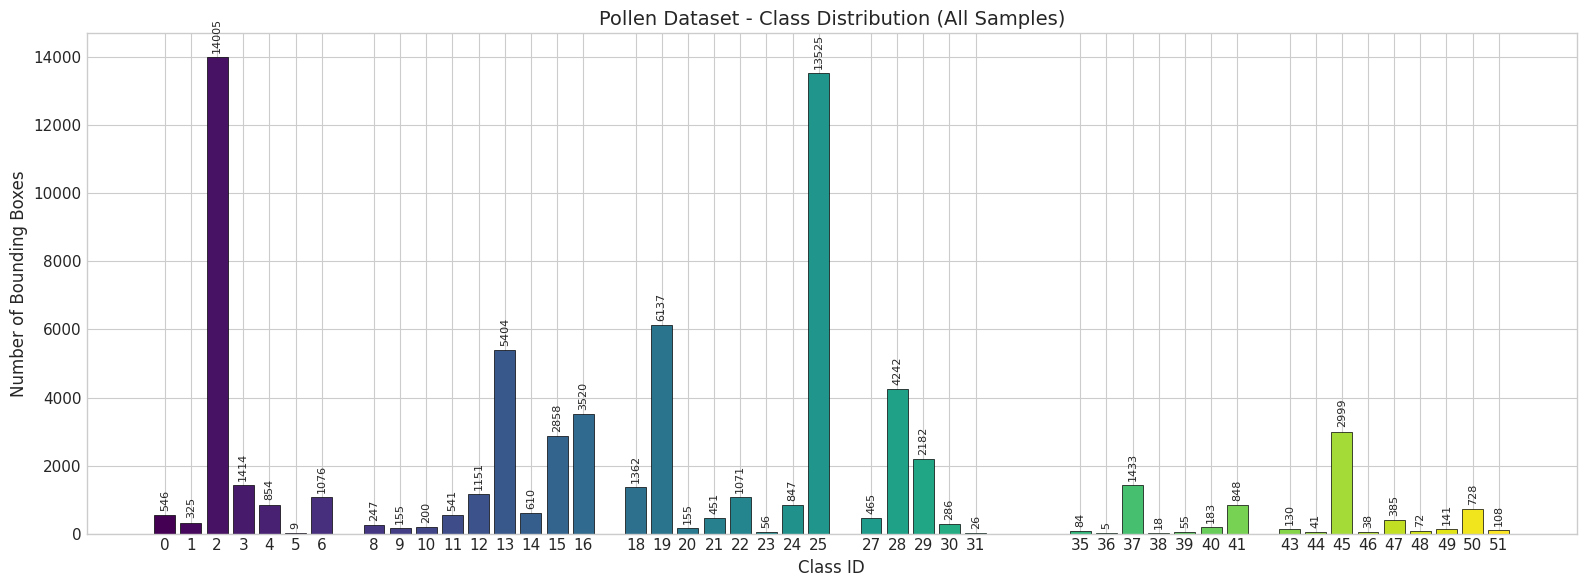

Saved: plots/class_distribution_all.png


In [7]:
# === PLOT 1: Class Distribution Bar Chart (Full Dataset) ===
fig, ax = plt.subplots(figsize=(16, 6))

class_ids = sorted(total_counts.keys())
counts = [total_counts[c] for c in class_ids]

colors = plt.cm.viridis(np.linspace(0, 1, len(class_ids)))
bars = ax.bar(class_ids, counts, color=colors, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Class ID')
ax.set_ylabel('Number of Bounding Boxes')
ax.set_title('Pollen Dataset - Class Distribution (All Samples)')
ax.set_xticks(class_ids)
ax.set_xticklabels(class_ids, rotation=0)

# Add value labels on top of bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax.annotate(f'{count}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=8, rotation=90)

plt.tight_layout()
plt.savefig('plots/class_distribution_all.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/class_distribution_all.png")

In [8]:
# (Train/val split comparison removed — EDA now operates on full dataset)


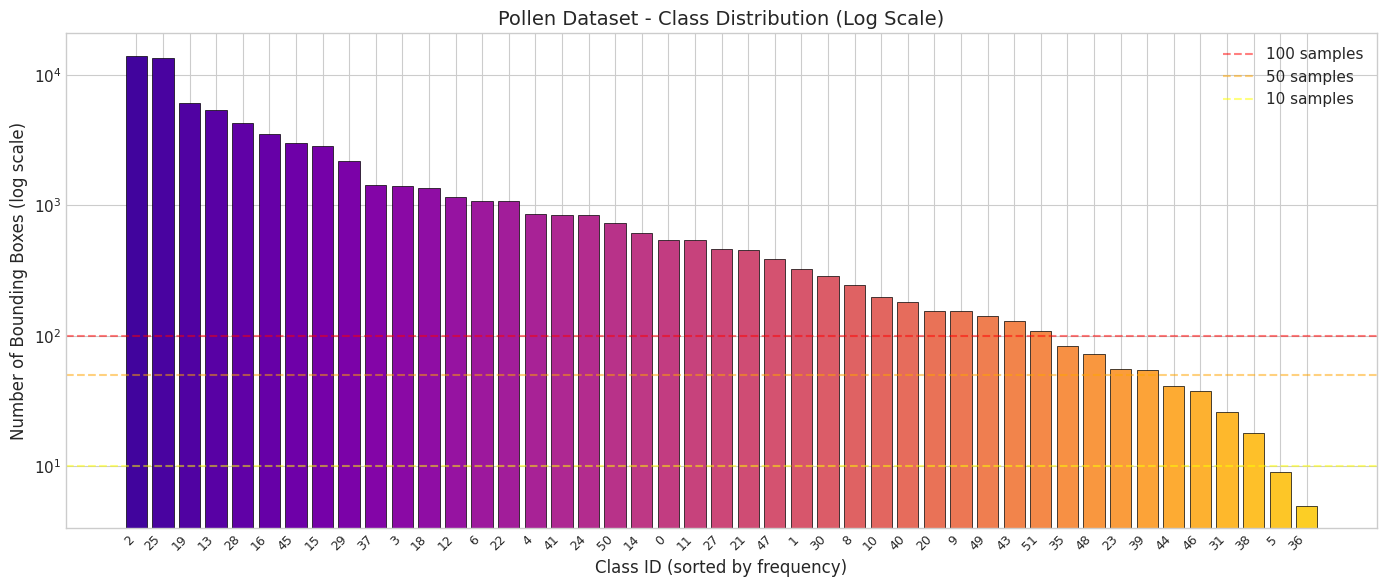

Saved: plots/class_distribution_logscale.png


In [9]:
# === PLOT 3: Log-scale Distribution (to visualize minority classes) ===
fig, ax = plt.subplots(figsize=(14, 6))

# Sort by count descending
sorted_data = total_df.sort_values('count', ascending=False)
class_ids_sorted = sorted_data['class_id'].tolist()
total_counts_sorted = sorted_data['count'].tolist()

colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(class_ids_sorted)))
bars = ax.bar(range(len(class_ids_sorted)), total_counts_sorted, color=colors, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Class ID (sorted by frequency)')
ax.set_ylabel('Number of Bounding Boxes (log scale)')
ax.set_title('Pollen Dataset - Class Distribution (Log Scale)')
ax.set_yscale('log')
ax.set_xticks(range(len(class_ids_sorted)))
ax.set_xticklabels(class_ids_sorted, rotation=45, ha='right', fontsize=9)

ax.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='100 samples')
ax.axhline(y=50, color='orange', linestyle='--', alpha=0.5, label='50 samples')
ax.axhline(y=10, color='yellow', linestyle='--', alpha=0.5, label='10 samples')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('plots/class_distribution_logscale.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/class_distribution_logscale.png")

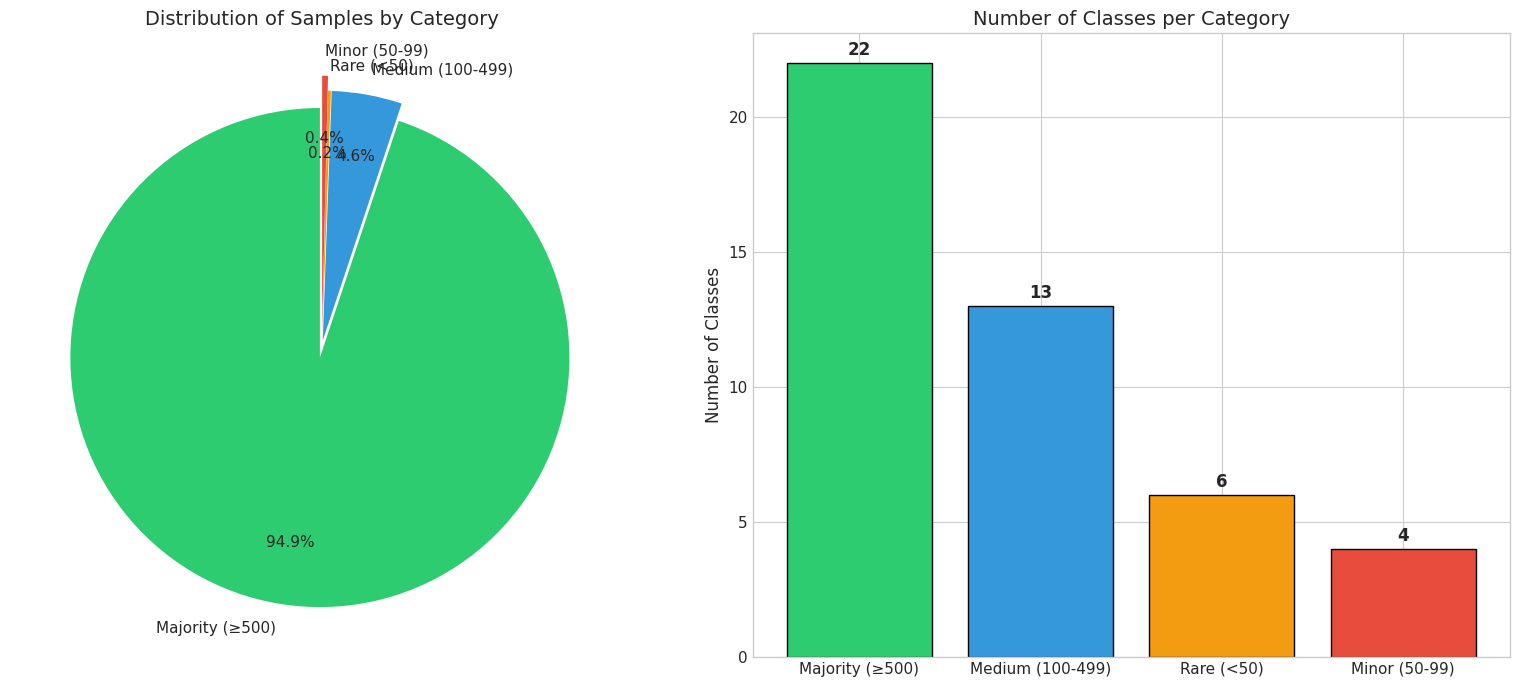


=== Category Breakdown ===
Majority (≥500): 22 classes - Class IDs: [0, 2, 3, 4, 6, 11, 12, 13, 14, 15, 16, 18, 19, 22, 24, 25, 28, 29, 37, 41, 45, 50]
Medium (100-499): 13 classes - Class IDs: [1, 8, 9, 10, 20, 21, 27, 30, 40, 43, 47, 49, 51]
Rare (<50): 6 classes - Class IDs: [5, 31, 36, 38, 44, 46]
Minor (50-99): 4 classes - Class IDs: [23, 35, 39, 48]


In [10]:
# === PLOT 4: Imbalance Analysis Pie Chart ===
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Categorize classes by sample count
def categorize_by_count(count):
    if count >= 500:
        return 'Majority (≥500)'
    elif count >= 100:
        return 'Medium (100-499)'
    elif count >= 50:
        return 'Minor (50-99)'
    else:
        return 'Rare (<50)'

category_counts = {}
category_classes = {}
for class_id in sorted(total_counts.keys()):
    count = total_counts[class_id]
    cat = categorize_by_count(count)
    category_counts[cat] = category_counts.get(cat, 0) + count
    category_classes[cat] = category_classes.get(cat, []) + [class_id]

# Pie chart of samples per category
ax1 = axes[0]
labels = list(category_counts.keys())
sizes = list(category_counts.values())
colors_pie = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
explode = (0.05, 0.02, 0.02, 0.08)

wedges, texts, autotexts = ax1.pie(sizes, labels=labels, colors=colors_pie, explode=explode,
                                    autopct='%1.1f%%', startangle=90, pctdistance=0.75)
ax1.set_title('Distribution of Samples by Category')

# Bar chart of number of classes per category
ax2 = axes[1]
num_classes_per_cat = {k: len(v) for k, v in category_classes.items()}
bars = ax2.bar(num_classes_per_cat.keys(), num_classes_per_cat.values(), color=colors_pie, edgecolor='black')
ax2.set_ylabel('Number of Classes')
ax2.set_title('Number of Classes per Category')
for bar in bars:
    height = bar.get_height()
    ax2.annotate(f'{int(height)}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/class_category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Category Breakdown ===")
for cat, classes in category_classes.items():
    print(f"{cat}: {len(classes)} classes - Class IDs: {classes}")

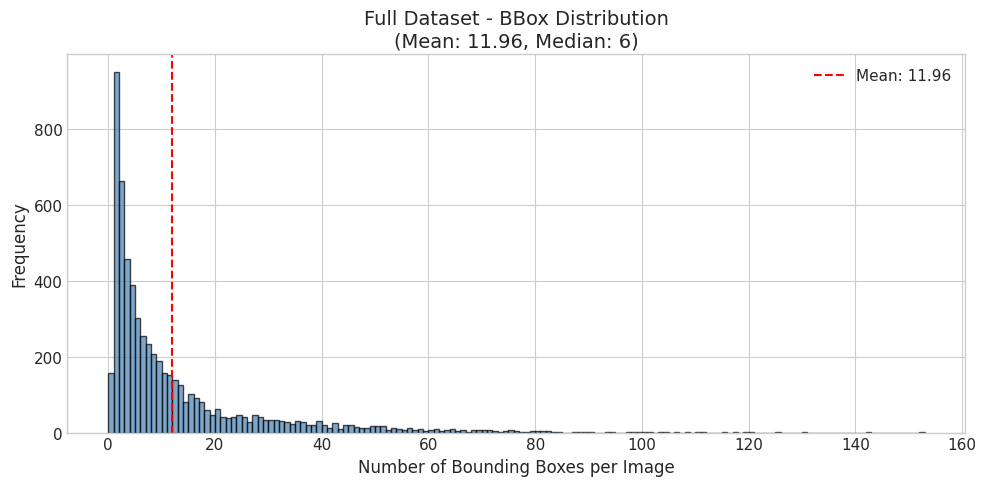

Saved: plots/bbox_per_image_distribution.png


In [11]:
# === PLOT 5: Bounding Boxes per Image Distribution ===
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(all_bbox_counts, bins=range(0, max(all_bbox_counts) + 2),
        color='steelblue', edgecolor='black', alpha=0.7)
ax.set_xlabel('Number of Bounding Boxes per Image')
ax.set_ylabel('Frequency')
ax.set_title(
    f'Full Dataset - BBox Distribution\n'
    f'(Mean: {np.mean(all_bbox_counts):.2f}, Median: {np.median(all_bbox_counts):.0f})'
)
ax.axvline(np.mean(all_bbox_counts), color='red', linestyle='--',
           label=f'Mean: {np.mean(all_bbox_counts):.2f}')
ax.legend()

plt.tight_layout()
plt.savefig('plots/bbox_per_image_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/bbox_per_image_distribution.png")

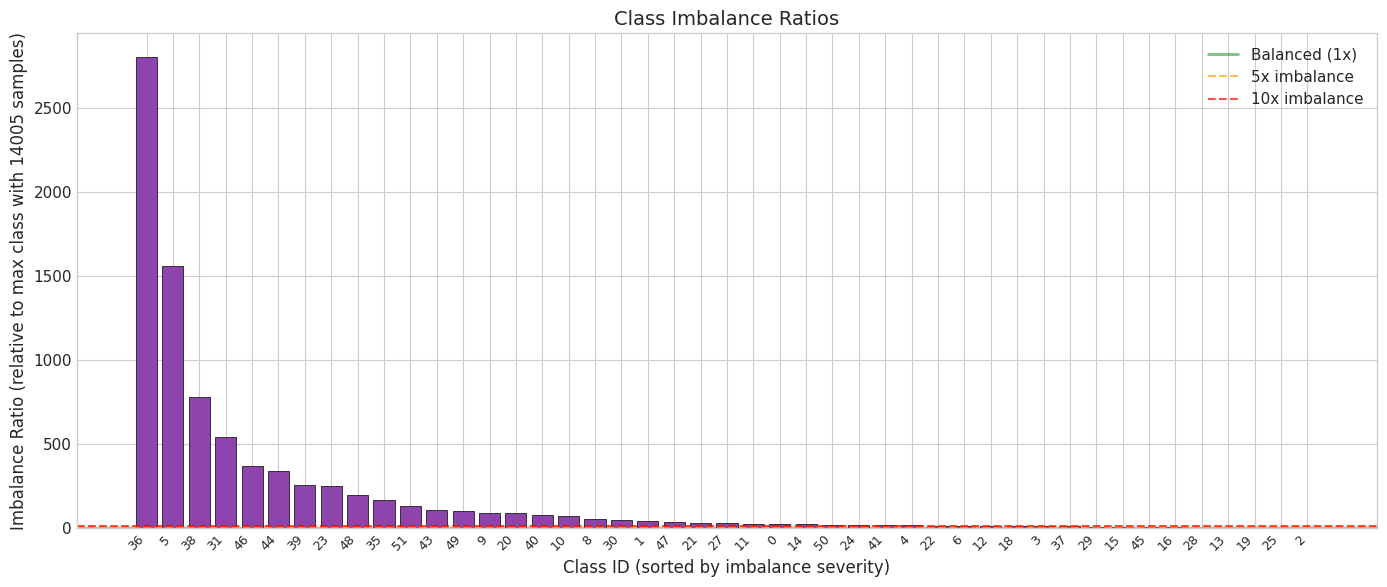

Saved: plots/imbalance_ratios.png


In [12]:
# === PLOT 6: Imbalance Ratio Visualization ===
fig, ax = plt.subplots(figsize=(14, 6))

# Calculate imbalance ratios relative to the majority class
max_count = total_df['count'].max()
imbalance_series = (max_count / total_df.set_index('class_id')['count']).sort_values(ascending=False)
class_ids_imb = imbalance_series.index.tolist()
ratios = imbalance_series.values.tolist()

# Color by severity
colors = []
for r in ratios:
    if r <= 2:
        colors.append('#27ae60')  # Balanced (green)
    elif r <= 5:
        colors.append('#f39c12')  # Moderate imbalance (orange)
    elif r <= 10:
        colors.append('#e74c3c')  # Severe imbalance (red)
    else:
        colors.append('#8e44ad')  # Extreme imbalance (purple)

bars = ax.bar(range(len(class_ids_imb)), ratios, color=colors, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Class ID (sorted by imbalance severity)')
ax.set_ylabel(f'Imbalance Ratio (relative to max class with {max_count} samples)')
ax.set_title('Class Imbalance Ratios')

ax.axhline(y=1, color='green', linestyle='-', alpha=0.5, linewidth=2, label='Balanced (1x)')
ax.axhline(y=5, color='orange', linestyle='--', alpha=0.7, label='5x imbalance')
ax.axhline(y=10, color='red', linestyle='--', alpha=0.7, label='10x imbalance')

ax.set_xticks(range(len(class_ids_imb)))
ax.set_xticklabels(class_ids_imb, rotation=45, ha='right', fontsize=9)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('plots/imbalance_ratios.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plots/imbalance_ratios.png")

In [13]:
# === Summary Statistics ===
print("=" * 60)
print("POLLEN DATASET EDA SUMMARY")
print("=" * 60)

print("\n📊 Dataset Size:")
print(f"  Total images:      {len(all_img_classes):,}")
print(f"  Number of classes: {len(total_counts)}")

print("\n📦 Bounding Boxes:")
print(f"  Total bboxes:      {sum(all_bbox_counts):,}")
print(f"  Avg bboxes/image:  {np.mean(all_bbox_counts):.2f}")

print("\n⚖️ Class Balance Metrics:")
counts_array = np.array(list(total_counts.values()))
print(f"  Max class count:   {counts_array.max():,} (class {max(total_counts, key=total_counts.get)})")
print(f"  Min class count:   {counts_array.min():,} (class {min(total_counts, key=total_counts.get)})")
print(f"  Mean count:        {counts_array.mean():.1f}")
print(f"  Median count:      {np.median(counts_array):.0f}")
print(f"  Std deviation:     {counts_array.std():.1f}")
print(f"  Max/Min ratio:     {counts_array.max() / counts_array.min():.1f}x")

print("\n📈 Imbalance Categories:")
for cat, classes in category_classes.items():
    total_samples = sum(total_counts[c] for c in classes)
    print(f"  {cat}: {len(classes)} classes, {total_samples:,} samples")

max_count = counts_array.max()
print("\n🔴 Most Underrepresented Classes (bottom 10):")
sorted_classes = sorted(total_counts.items(), key=lambda x: x[1])
for class_id, count in sorted_classes[:10]:
    ratio = max_count / count
    print(f"  Class {class_id:2d}: {count:4d} samples ({ratio:.1f}x imbalance)")

print("\n🟢 Most Overrepresented Classes (top 10):")
for class_id, count in sorted_classes[-10:][::-1]:
    print(f"  Class {class_id:2d}: {count:4d} samples")

POLLEN DATASET EDA SUMMARY

📊 Dataset Size:
  Total images:      5,936
  Number of classes: 45

📦 Bounding Boxes:
  Total bboxes:      70,988
  Avg bboxes/image:  11.96

⚖️ Class Balance Metrics:
  Max class count:   14,005 (class 2)
  Min class count:   5 (class 36)
  Mean count:        1577.5
  Median count:      465
  Std deviation:     2983.1
  Max/Min ratio:     2801.0x

📈 Imbalance Categories:
  Majority (≥500): 22 classes, 67,353 samples
  Medium (100-499): 13 classes, 3,231 samples
  Rare (<50): 6 classes, 137 samples
  Minor (50-99): 4 classes, 267 samples

🔴 Most Underrepresented Classes (bottom 10):
  Class 36:    5 samples (2801.0x imbalance)
  Class  5:    9 samples (1556.1x imbalance)
  Class 38:   18 samples (778.1x imbalance)
  Class 31:   26 samples (538.7x imbalance)
  Class 46:   38 samples (368.6x imbalance)
  Class 44:   41 samples (341.6x imbalance)
  Class 39:   55 samples (254.6x imbalance)
  Class 23:   56 samples (250.1x imbalance)
  Class 48:   72 samples (19

In [14]:
# Save summary statistics to file
import json

summary = {
    'dataset_stats': {
        'total_images': len(all_img_classes),
        'num_classes': len(total_counts),
        'total_bboxes': sum(all_bbox_counts),
        'avg_bboxes_per_image': float(np.mean(all_bbox_counts)),
    },
    'class_balance': {
        'max_count': int(counts_array.max()),
        'min_count': int(counts_array.min()),
        'mean_count': float(counts_array.mean()),
        'median_count': float(np.median(counts_array)),
        'std_count': float(counts_array.std()),
        'imbalance_ratio': float(counts_array.max() / counts_array.min()),
    },
    'class_distribution': {str(k): int(v) for k, v in total_counts.items()},
    'category_breakdown': {
        cat: {'num_classes': len(classes), 'class_ids': classes}
        for cat, classes in category_classes.items()
    }
}

with open('plots/dataset_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Summary saved to: plots/dataset_summary.json")
print("\n✅ EDA Complete! All plots saved to 'plots/' directory.")

Summary saved to: plots/dataset_summary.json

✅ EDA Complete! All plots saved to 'plots/' directory.
